# COGS 108 - Data Checkpoint

## Authors


This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Thalesh: Conceptualization, Methodology, Analysis, Writing – original draft

Redan: Data curation, Experimental investigation, Visualization

Ghislain: Background research, Analysis, Writing – review & editing

Henrique: Software, Project administration, Visualization

## Research Question

Is median household income associated with median home prices across U.S. metropolitan areas after controlling for local unemployment rates in 2023? Using metropolitan-level data, we analyze median home price as a function of median household income, with unemployment rate included as a control variable because local labor market conditions may influence both household income levels and housing demand. Areas with higher unemployment may experience reduced purchasing power and lower housing demand, which could independently affect home prices. Controlling for unemployment therefore helps isolate the association between income and housing prices from broader economic conditions. We emphasize this control because unemployment can confound the income–price relationship: in weaker labor markets both income and housing demand tend to fall, so without holding unemployment constant we could misattribute to income alone effects that partly reflect local job conditions. We apply correlation analysis and multiple linear regression to assess whether income remains a statistically significant predictor of housing prices after accounting for these factors. This is a statistical inference task focused on estimating relationships rather than prediction.


## Background and Prior Work

Housing prices vary widely across U.S. metropolitan areas, reflecting differences in underlying regional economic conditions rather than a single determinant. Economic theory predicts that higher household income increases housing demand and can raise home prices, but empirical evidence suggests this relationship is not always stable. A Federal Reserve study examining metropolitan housing markets finds that the long-run relationship between income and house prices is weaker and less consistent than commonly assumed, indicating that additional local factors may influence price variation (Federal Reserve, 2003). Labor market conditions are one such factor, as unemployment affects income stability, credit access, and housing demand, and metropolitan-level data show substantial variation in unemployment rates across regions (Bureau of Labor Statistics, n.d.). Other peer-reviewed research using metropolitan housing data further demonstrates that housing prices respond to regional economic conditions in complex and heterogeneous ways across locations and populations (Journal of Public Economics study). These findings highlight that income alone may not fully explain price differences and that failing to account for broader economic conditions could bias estimates of the income–price relationship. Motivated by this literature, our analysis examines the association between median household income and metropolitan home prices while controlling for unemployment to better isolate the relationship of interest.

https://www.bls.gov/web/metro/laummtrk.htm - unemployment rate by area

https://www.sciencedirect.com/science/article/abs/pii/S0047272713001904 - household prices by area

https://www.federalreserve.gov/pubs/feds/2003/200317/200317pap.pdf - Relationship between House Prices and Income

## Hypothesis


After controlling for local unemployment rates, U.S. metropolitan areas with higher median household incomes will have higher median home prices, because higher incomes increase purchasing power and housing demand, intensifying competition for a relatively fixed housing supply even when labor market conditions are held constant.

## Data

Dataset 1
Name: Median Household Income (2023) and Median Home Value (2023)

Source: U.S. Census Bureau — American Community Survey (ACS) 1-year estimates

Link:
https://api.census.gov/data/2023/acs/acs1?get=NAME,B19013_001E,B25077_001E&for=metropolitan%20statistical%20area/micropolitan%20statistical%20area:*

Number of observations:
393 metropolitan areas

Variables:
1. Median Household Income (2023)
   - Variable code: B19013_001E
   - Measures the median household income for each metropolitan area.
   - Used as the primary independent variable to evaluate whether areas with higher income tend to have higher housing prices.

2. Median Home Value (2023)
   - Variable code: B25077_001E
   - Measures the median value of owner-occupied housing units in each metropolitan area.
   - Used as the dependent variable in the analysis.

Expected relationship:
Economic theory suggests a positive association between income and housing prices. Metropolitan areas with higher household incomes are expected to have higher housing demand, which may increase median home values.

Shortcomings:
- Median home value includes only owner-occupied housing units and excludes rental markets.
- Data are cross-sectional, so results reflect association rather than causation.
- Metropolitan-level averages may hide variation within cities.
- ACS estimates include sampling error.


Dataset 2
Name: Annual Metropolitan Unemployment Rate (2023)

Source: U.S. Bureau of Labor Statistics — Local Area Unemployment Statistics (LAUS)

Link:
https://www.bls.gov/lau/metro-annual-unemployment-rates.htm

Number of observations:
Approximately 390 metropolitan areas (after cleaning and matching).

Variables:
1. Unemployment Rate (2023)
   - Annual average unemployment rate for each metropolitan area.
   - Used as a control variable in the regression model.

Purpose in the study:
Unemployment is included because local labor market conditions may influence both household income levels and housing demand. Areas with higher unemployment may experience reduced purchasing power and weaker housing demand, which could independently affect home prices. Controlling for unemployment helps isolate the association between income and housing prices.

Expected relationship:
Higher unemployment rates are expected to be negatively associated with median home values.

Shortcomings:
- Annual averages do not capture seasonal fluctuations in employment.
- Unemployment rate may not fully represent overall economic conditions.
- Possible measurement differences across metropolitan areas.


Research question context:
Using metropolitan-level data, we analyze median home price as a function of median household income, with unemployment rate included as a control variable because local labor market conditions may influence both household income levels and housing demand. Areas with higher unemployment may experience reduced purchasing power and lower housing demand, which could independently affect home prices. Controlling for unemployment therefore helps isolate the association between income and housing prices from broader economic conditions. We apply correlation analysis and multiple linear regression to assess whether income remains a statistically significant predictor of housing prices after accounting for these factors. This is a statistical inference task focused on estimating relationships rather than prediction.

Combining the datasets:
We will combine these datasets by merging on the metropolitan area name (NAME), which we standardize to the format "City, ST Metro Area" in both datasets to ensure consistent matching. After cleaning each dataset separately (as shown in the sections below), we perform an inner join on NAME to create a unified dataset where each row represents a metropolitan area in 2023 with its median household income, median home value, and unemployment rate. This merge yields approximately 386–387 metropolitan areas that appear in both datasets, allowing us to analyze the relationship between income and home prices while controlling for unemployment. We use an inner join to keep only metros present in both sources, ensuring complete data for all variables in our regression analysis.

In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [ ]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

### Metro Median Household Income and Home Values (2023)

**Metrics and units.** This dataset describes U.S. metropolitan areas in 2023. The main variables are: **median_income** (median household income in current-year dollars, not adjusted for inflation or cost of living); **median_home_value** (median value of owner-occupied housing units in dollars); and **population** (total population of the metro area). Income and home values are in nominal dollars, so cross-metro comparisons reflect both real economic differences and regional price levels. Higher values generally indicate wealthier or higher-cost areas (e.g., many California metros have high income and high home values). **NAME** is the official Census Bureau–style metro area name (e.g., "Austin-Round Rock, TX Metro Area"). One row per metro area; the file is already in a tidy format (each row is an observation, each column is a variable). We chose this dataset because it supplies both our outcome (median home value) and our main predictor (median household income) at the same metro geography and year (2023), which is needed to test whether income is associated with home prices after controlling for local labor market conditions.

**Data acquisition (API).** We obtained median home values (and similarly, median household income and population for the combined dataset) by calling the U.S. Census Bureau’s American Community Survey (ACS) API. We used a Census API key for authentication and requested the relevant variables (e.g., B25077_001E for median home value) for all metropolitan and micropolitan statistical areas. Using pandas we read the API response as JSON, fixed the header row, renamed the estimate column to a readable name, kept only rows for metro areas (filtering by NAME containing \"Metro Area\"), converted values to numeric, dropped missing entries, and saved the result to CSV. The technical code below was used to pull the data before the load/clean steps in this notebook.

**Concerns and limitations.** The data are aggregate metro-level statistics, so we cannot infer individual-level income–housing relationships. Median income and median home value are both central tendencies and can mask inequality within metros. Definitions of "metro area" (CBSA) can change over time and may include counties with very different labor and housing markets. Nominal dollar values do not adjust for regional cost of living, so the same dollar income or home value may imply different real purchasing power across regions. We use this dataset as the primary source for our outcome (median home value) and main predictor (median household income), and we will combine it with unemployment data by matching on metro name or identifier.


In [ ]:
# Data acquisition: fetch median home values from Census Bureau ACS API
"""
import pandas as pd

YEAR = "2023"
API_KEY = "----------------"  # Census API key (redacted)

url = (
    f"https://api.census.gov/data/{YEAR}/acs/acs1"
    "?get=NAME,B25077_001E"
    "&for=metropolitan%20statistical%20area/micropolitan%20statistical%20area:*"
    f"&key={API_KEY}"
)

print("Downloading median home values...")

df = pd.read_json(url)

# Fix headers
df.columns = df.iloc[0]
df = df[1:]

# Rename column
df = df.rename(columns={
    "B25077_001E": "median_home_value"
})

# Keep only metro areas
df = df[df["NAME"].str.contains("Metro Area")]

# Convert to numeric
df["median_home_value"] = pd.to_numeric(df["median_home_value"], errors="coerce")

# Drop missing
df = df.dropna()

# Add year column
df["year"] = int(YEAR)

# Save CSV
df.to_csv("metro_home_values_2023.csv", index=False)

print("Saved as metro_home_values_2023.csv")
print(df.head())
print("Shape:", df.shape)
"""

In [11]:
# 1) Load the dataset from data/00-raw
import pandas as pd
import numpy as np
import os

raw_path = 'data/00-raw/median_household_icnome2023.csv'
if not os.path.isfile(raw_path):
    raw_path = 'median_household_icnome2023.csv'
df1 = pd.read_csv(raw_path)
print("Loaded from:", raw_path)

# 2) Tidy check: one row per metro, one column per variable — already tidy
print("\n--- Tidy structure: one row per metro, one column per variable ---")
print(df1.head(3))

# 3) Dataset size
print("\n--- Dataset size ---")
print("Shape:", df1.shape)
print("Rows:", df1.shape[0], "metro areas; Columns:", df1.shape[1])

# 4) Missingness: how much, where, and whether systematic
print("\n--- Missingness ---")
missing = df1.isna().sum()
print(missing)
print("Total missing:", df1.isna().sum().sum())
if df1.isna().any().any():
    print("Rows with any missing:", df1.isna().any(axis=1).sum())
else:
    print("No missing values; missingness is not a concern (no systematic pattern to assess).")

# 5) Outliers / suspicious entries (flag using IQR for numeric columns)
print("\n--- Outliers (IQR method) ---")
numeric_cols = ['median_income', 'median_home_value', 'population']
for col in numeric_cols:
    Q1, Q3 = df1[col].quantile(0.25), df1[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    flags = df1[(df1[col] < low) | (df1[col] > high)]
    if len(flags) > 0:
        print(f"  {col}: {len(flags)} potential outlier(s) outside [{low:.0f}, {high:.0f}]")
        print(flags[['NAME', col]].to_string())
    else:
        print(f"  {col}: no outliers flagged at 1.5*IQR")
# Sanity: no zero/negative income or home value
suspicious = df1[(df1['median_income'] <= 0) | (df1['median_home_value'] <= 0)]
if len(suspicious) > 0:
    print("Suspicious (non-positive income or home value):", suspicious)
else:
    print("No non-positive income or home values.")

# 6) Clean and justify choices
df1_clean = df1.copy()
for c in numeric_cols:
    df1_clean[c] = pd.to_numeric(df1_clean[c], errors='coerce')
before = len(df1_clean)
df1_clean = df1_clean.dropna(subset=numeric_cols, how='any')
if len(df1_clean) < before:
    print(f"\nDropped {before - len(df1_clean)} rows with non-numeric or missing key variables.")
print("Final cleaned row count:", len(df1_clean))

# 7) Write final wrangled data to data/02-processed
os.makedirs('data/02-processed', exist_ok=True)
out_path = 'data/02-processed/median_household_income_home_values_2023.csv'
df1_clean.to_csv(out_path, index=False)
print(f"\nSaved final dataset to {out_path}")

# Summary statistics for key variables
print("\n--- Summary statistics (key variables) ---")
print(df1_clean[['median_income', 'median_home_value', 'population']].describe())

# Match check with Dataset #2 (unemployment): NAME is the join key
unemp_path = 'data/02-processed/metro_unemployment_2023.csv'
if os.path.isfile(unemp_path):
    unemp = pd.read_csv(unemp_path)
    income_names = set(df1_clean['NAME'])
    unemp_names = set(unemp['NAME'])
    matched = income_names & unemp_names
    only_income = income_names - unemp_names
    print("\n--- Name match with unemployment dataset (join key: NAME) ---")
    print(f"  Metros in this (income) dataset: {len(income_names)}")
    print(f"  Metros in unemployment dataset: {len(unemp_names)}")
    print(f"  Names that match (can join):    {len(matched)}")
    if only_income:
        print(f"  Only in income (no unemp match): {len(only_income)}", list(only_income)[:8], "..." if len(only_income) > 8 else "")
else:
    print("\n--- Join key: NAME. Run Dataset #2 and re-run this cell to check match with unemployment. ---")


Loaded from: data/00-raw/median_household_icnome2023.csv

--- Tidy structure: one row per metro, one column per variable ---
                       NAME  median_income  median_home_value  population
0    Abilene, TX Metro Area          61262             180400      180224
1  Aguadilla, PR Metro Area          21290             136500      250435
2      Akron, OH Metro Area          70125             216000      698398

--- Dataset size ---
Shape: (393, 4)
Rows: 393 metro areas; Columns: 4

--- Missingness ---
NAME                 0
median_income        0
median_home_value    0
population           0
dtype: int64
Total missing: 0
No missing values; missingness is not a concern (no systematic pattern to assess).

--- Outliers (IQR method) ---
  median_income: 18 potential outlier(s) outside [37368, 103300]
                                                        NAME  median_income
1                                   Aguadilla, PR Metro Area          21290
17                               

**Data cleanliness (Dataset 1).** Below we visualize missingness and the distributions of key numeric variables to show that the data are complete and values are in plausible ranges.

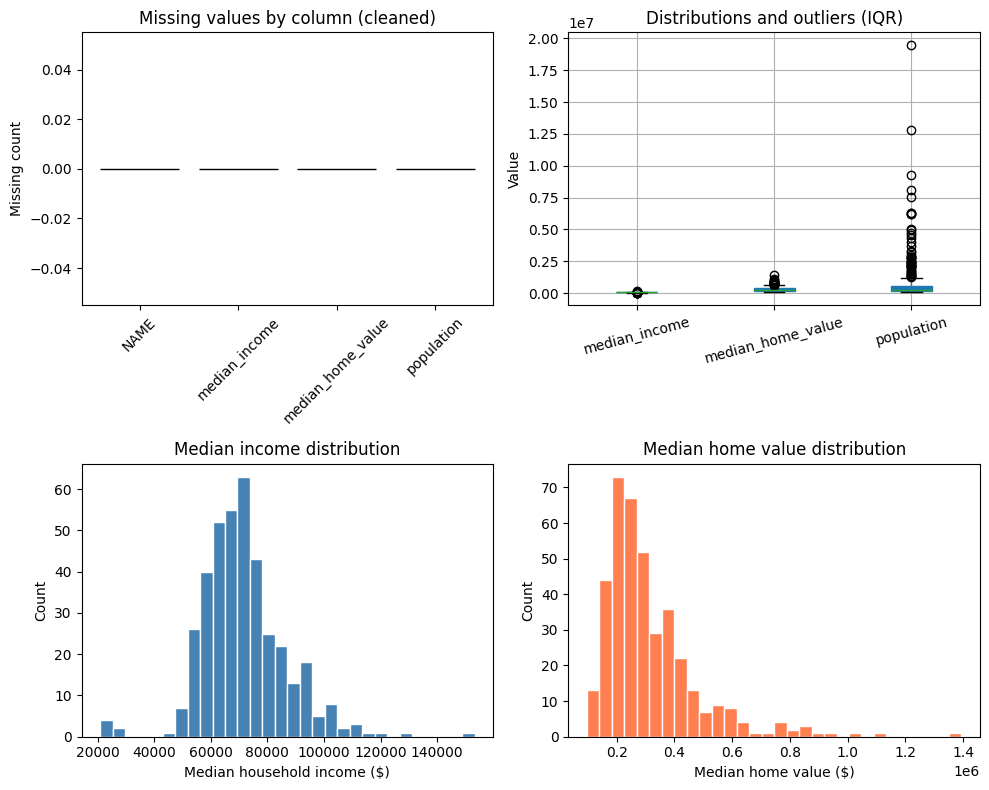

In [12]:
# Visualize data cleanliness: Dataset 1 (income & home values)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1) Missingness per column (cleaned data)
missing = df1_clean.isna().sum()
axes[0, 0].bar(missing.index, missing.values, color='steelblue', edgecolor='black')
axes[0, 0].set_ylabel("Missing count")
axes[0, 0].set_title("Missing values by column (cleaned)")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2) Boxplots for key numeric variables (show spread and outliers)
numeric_cols = ['median_income', 'median_home_value', 'population']
df1_clean[numeric_cols].boxplot(ax=axes[0, 1], patch_artist=True)
axes[0, 1].set_ylabel("Value")
axes[0, 1].set_title("Distributions and outliers (IQR)")
axes[0, 1].tick_params(axis='x', rotation=15)

# 3) Histogram of median_income
axes[1, 0].hist(df1_clean['median_income'], bins=30, color='steelblue', edgecolor='white')
axes[1, 0].set_xlabel("Median household income ($)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Median income distribution")

# 4) Histogram of median_home_value
axes[1, 1].hist(df1_clean['median_home_value'], bins=30, color='coral', edgecolor='white')
axes[1, 1].set_xlabel("Median home value ($)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Median home value distribution")

plt.tight_layout()
plt.show()

### Metro Annual Unemployment Rate (2023)

**Metrics and units.** This dataset comes from the Bureau of Labor Statistics (BLS) Local Area Unemployment Statistics (LAUS) and gives annual average unemployment rates for U.S. metropolitan areas from 2020 to 2024. The **unemployment rate** is in **percentage points** (e.g., 4.5 means 4.5% of the labor force was unemployed). Values typically range from about 2% to the mid-20s; the BLS defines unemployed as people without a job who are available and have looked for work in the past four weeks. Lower rates indicate tighter labor markets; higher rates can reflect weaker local demand or seasonal/structural factors (e.g., agricultural or tourism-dependent areas). For our analysis we use the **2023** column as the control variable. The **Metropolitan area title** is the BLS metro name (e.g., "Anniston-Oxford, AL"); **State FIPS code** and **LAUS area code** identify the area. The raw file has one row per metro with years as columns; we keep one row per metro and use only the 2023 rate for a tidy analysis-ready table. We chose this dataset because it provides a 2023 unemployment rate for each metro at the same geography and year as our income and housing data, allowing us to control for local labor market conditions and better isolate the association between household income and home prices.

**Concerns and limitations.** Metro boundaries in BLS data may not exactly match those in our income/housing dataset (e.g., Census CBSA definitions), so name-based merging may require standardizing labels (e.g., appending " Metro Area"). The annual average smooths seasonal variation. Unemployment is a proxy for local labor market conditions and does not capture underemployment or labor-force participation. Data are official BLS estimates and subject to revision. We use this dataset solely as a control variable to isolate the income–home price association from broader economic conditions.

In [13]:
# 1) Load the dataset 
import pandas as pd
import numpy as np
import os

raw_path = 'data/00-raw/annual_unnemployment_rate2023.csv'
if not os.path.isfile(raw_path):
    raw_path = 'annual_unnemployment_rate2023.csv'
df2 = pd.read_csv(raw_path, header=1)
print("Loaded from:", raw_path)

# Year column may be read as int 2023 or str '2023'
col_2023 = 2023 if 2023 in df2.columns else '2023' if '2023' in df2.columns else df2.columns[6]
metro_col = 'Metropolitan area title'
# Drop footer rows 
df2 = df2.dropna(subset=[metro_col, col_2023], how='any')
df2['unemployment_rate_2023'] = pd.to_numeric(df2[col_2023], errors='coerce')
df2 = df2.dropna(subset=['unemployment_rate_2023'], how='any')
# Rename for clarity and keep key columns
df2 = df2.rename(columns={metro_col: 'metro_title'})
df2 = df2[['metro_title', 'unemployment_rate_2023']].copy()
# Create join key to match Dataset #1 NAME format: "City, ST Metro Area"
df2['NAME'] = df2['metro_title'] + ' Metro Area'
# Normalize BLS naming to match income dataset: "St. Louis, MO-IL1" -> "St. Louis, MO-IL"
df2['NAME'] = df2['NAME'].str.replace('MO-IL1 Metro Area', 'MO-IL Metro Area', regex=False)
# Use same format as Dataset 1: metro_title = standardized name so both datasets align
df2['metro_title'] = df2['NAME'].copy()

# 2) Tidy: one row per metro, one column per variable 
print("\n--- Tidy structure: one row per metro, key variables ---")
print(df2.head(5))

# 3) Dataset size
print("\n--- Dataset size ---")
print("Shape:", df2.shape)
print("Rows:", df2.shape[0], "metro areas; Columns:", df2.shape[1])

# 4) Missingness
print("\n--- Missingness ---")
print(df2.isna().sum())
print("Total missing:", df2.isna().sum().sum())
if df2.isna().any().any():
    print("Rows with any missing:", df2.isna().any(axis=1).sum())
else:
    print("No missing values in key columns.")

# 5) Outliers / suspicious entries (unemployment rate in percentage points)
print("\n--- Outliers (IQR) and sanity checks ---")
Q1, Q3 = df2['unemployment_rate_2023'].quantile(0.25), df2['unemployment_rate_2023'].quantile(0.75)
IQR = Q3 - Q1
low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
flags = df2[(df2['unemployment_rate_2023'] < low) | (df2['unemployment_rate_2023'] > high)]
if len(flags) > 0:
    print(f"  unemployment_rate_2023: {len(flags)} potential outlier(s) outside [{low:.1f}, {high:.1f}]%")
    print(flags[['NAME', 'unemployment_rate_2023']].to_string())
else:
    print("  unemployment_rate_2023: no outliers flagged at 1.5*IQR")
# Sanity: rates should be 0–100
suspicious = df2[(df2['unemployment_rate_2023'] < 0) | (df2['unemployment_rate_2023'] > 100)]
print("Non-[0,100]% rates:", len(suspicious)); print(suspicious if len(suspicious) > 0 else "None.")

# 6) Clean and justify
df2_clean = df2.copy()
df2_clean = df2_clean.dropna(subset=['NAME', 'unemployment_rate_2023'], how='any')
print("\nFinal cleaned row count:", len(df2_clean))

# 7) Write final wrangled data to data/02-processed
os.makedirs('data/02-processed', exist_ok=True)
out_path = 'data/02-processed/metro_unemployment_2023.csv'
df2_clean.to_csv(out_path, index=False)
print(f"Saved final dataset to {out_path}")

# Optional: summary statistics
print("\n--- Summary statistics (unemployment_rate_2023) ---")
print(df2_clean['unemployment_rate_2023'].describe())

# Match check with Dataset #1 (income) and inner merge on NAME
income_path = 'data/02-processed/median_household_income_home_values_2023.csv'
df1_loaded = pd.read_csv(income_path) if os.path.isfile(income_path) else None
if df1_loaded is not None:
    income_names = set(df1_loaded['NAME'])
    unemp_names = set(df2_clean['NAME'])
    matched = income_names & unemp_names
    only_income = income_names - unemp_names
    only_unemp = unemp_names - income_names
    print("\n--- Name match with income dataset (join key: NAME) ---")
    print(f"  Metros in income dataset:     {len(income_names)}")
    print(f"  Metros in unemployment set:  {len(unemp_names)}")
    print(f"  Names that match (can join): {len(matched)}")
    if only_income:
        print(f"  Only in income (no unemp):   {len(only_income)}", list(only_income)[:8], "..." if len(only_income) > 8 else "")
    if only_unemp:
        print(f"  Only in unemployment:       {len(only_unemp)}", list(only_unemp))
    merged = df1_loaded.merge(df2_clean, on='NAME', how='inner')
    print(f"  Inner merge (analysis-ready): {len(merged)} rows. Columns:", list(merged.columns))
else:
    print("\n--- Run Dataset #1 first to check match and merge. Join key: NAME. ---")


Loaded from: data/00-raw/annual_unnemployment_rate2023.csv

--- Tidy structure: one row per metro, key variables ---
                            metro_title  unemployment_rate_2023  \
0        Anniston-Oxford, AL Metro Area                     2.6   
1         Auburn-Opelika, AL Metro Area                     2.3   
2             Birmingham, AL Metro Area                     2.3   
3  Daphne-Fairhope-Foley, AL Metro Area                     2.2   
4                Decatur, AL Metro Area                     2.1   

                                   NAME  
0        Anniston-Oxford, AL Metro Area  
1         Auburn-Opelika, AL Metro Area  
2             Birmingham, AL Metro Area  
3  Daphne-Fairhope-Foley, AL Metro Area  
4                Decatur, AL Metro Area  

--- Dataset size ---
Shape: (387, 3)
Rows: 387 metro areas; Columns: 3

--- Missingness ---
metro_title               0
unemployment_rate_2023    0
NAME                      0
dtype: int64
Total missing: 0
No missing values in 

**Data cleanliness (Dataset 2).** Below we visualize missingness and the distribution of the unemployment rate to show that the data are complete and values are in a plausible range (0–100%).

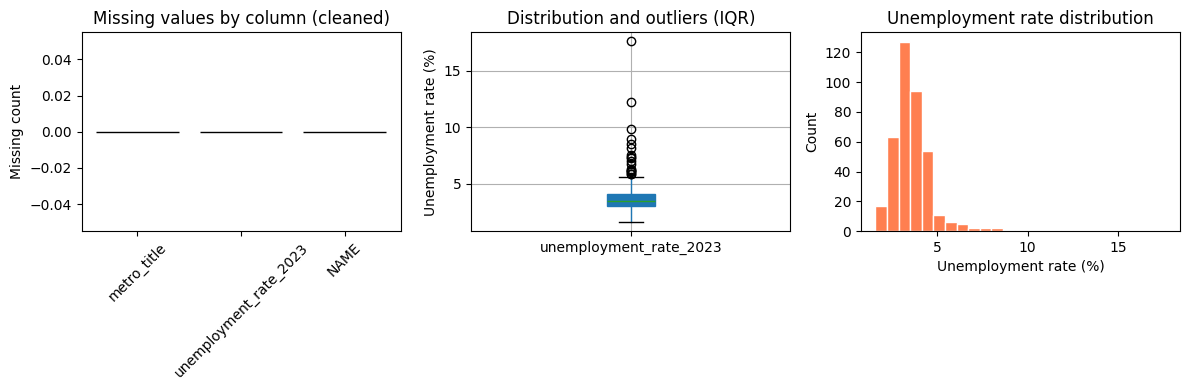

In [14]:
# Visualize data cleanliness: Dataset 2 (unemployment)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1) Missingness per column (cleaned data)
missing = df2_clean.isna().sum()
axes[0].bar(missing.index, missing.values, color='steelblue', edgecolor='black')
axes[0].set_ylabel("Missing count")
axes[0].set_title("Missing values by column (cleaned)")
axes[0].tick_params(axis='x', rotation=45)

# 2) Boxplot of unemployment_rate_2023
df2_clean[['unemployment_rate_2023']].boxplot(ax=axes[1], patch_artist=True)
axes[1].set_ylabel("Unemployment rate (%)")
axes[1].set_title("Distribution and outliers (IQR)")

# 3) Histogram of unemployment_rate_2023
axes[2].hist(df2_clean['unemployment_rate_2023'], bins=25, color='coral', edgecolor='white')
axes[2].set_xlabel("Unemployment rate (%)")
axes[2].set_ylabel("Count")
axes[2].set_title("Unemployment rate distribution")

plt.tight_layout()
plt.show()

## Ethics

When examining the association between median household income and median home prices across U.S. metropolitan areas, several ethical considerations should be addressed. First, the study relies on aggregated metropolitan-level data, which risks obscuring important within-area inequalities, such as disparities by race, neighborhood, or socioeconomic status; acknowledging this limitation is essential to avoid overgeneralized conclusions. Second, interpreting the relationship between income and home prices requires caution to prevent normative assumptions that rising prices are universally beneficial, as higher housing costs can exacerbate affordability challenges and displacement for lower-income residents. Third, because the analysis is observational and non-causal, it is ethically important to avoid policy recommendations that imply deterministic effects of income growth on housing markets without accounting for regulatory, historical, and structural factors. Finally, transparency in data sources, variable definitions, and modeling choices is necessary to ensure reproducibility and to prevent misinterpretation of results that could influence housing or urban policy debates.

## Team Expectations 

Communication (All members: Thalesh, Redan, Ghislain, Henrique) We will primarily communicate through Discord for quick coordination and questions, and use a shared Google Doc for longer writing and planning. Everyone is expected to respond within 24 hours unless they notify the group in advance.

Meetings (All members) We will meet once a week in person on campus to work together on coding and analysis tasks. If needed, we may also have short Discord calls for urgent issues.

Tone & Respect (All members) Our tone will be direct but respectful. If we disagree, we will explain our reasoning (e.g., “I think this approach might not work because…”) and allow others to respond before finalizing decisions.

Decision Making (Project lead rotates — coordinated by Henrique as project admin) Decisions will usually be made by majority agreement. For smaller implementation choices, the person responsible for that section (for example: Redan → visualization/data handling, Thalesh → methodology/analysis, Ghislain → research/writing) will have the final say.

Task Division (Role strengths)

Thalesh: analysis & methodology direction

Redan: data handling & visualization

Ghislain: research & writing review

Henrique: coding organization & project management

Even with specialization, everyone will review and contribute feedback to each section so the project remains collaborative.

Progress Tracking (Henrique maintains, everyone updates) We will track responsibilities using GitHub commits and a shared checklist so all members can see progress and remaining tasks.

Falling Behind Policy (All members responsible) If someone is falling behind, they should notify the group immediately. The team will redistribute work if needed, and if communication stops for an extended period we will follow course policy and contact the instructor.

Shared Responsibility (All members) Everyone agrees to contribute to brainstorming, coding, writing, and editing throughout the quarter rather than working on only one portion of the project.

## Project Timeline Proposal

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|------------|------------|------------|------------|
| Week 1 (after team formation) | Evening (Discord call) | Everyone reads project guidelines and brainstorms at least 2 research ideas individually | Proposed ideas and narrowed to housing affordability. Defined research question: income vs home value controlling for unemployment. Agreed on statistical inference approach (correlation + regression). |
| Week 2 | Afternoon (in-person library meeting) | Each member finds at least one dataset and evaluates geography level, year consistency, and merge feasibility | Compared Census, Zillow, and BLS datasets. Selected ACS income/home value + BLS unemployment. Verified metro compatibility and divided background research writing. |
| Week 3 | Short Discord check-in | Drafted proposal sections individually | Edited proposal together, refined hypothesis, finalized variables (income = independent, home value = dependent, unemployment = control). Justified unemployment as confounder. |
| Week 4 | In-person work session | Download datasets and inspect formats | Merged datasets, standardized metro names, removed mismatches, aligned year (2023), handled missing values, documented cleaning process. |
| Week 5 | Discord call | Finish cleaning and create initial plots | Interpreted EDA results, checked correlations, identified outliers and possible confounders, discussed transformations if needed. |
| Week 6 | In-person coding session | Prepare regression models | Implemented multiple regression: Home Value ~ Income + Unemployment. Compared models and checked coefficient significance and assumptions. |
| Week 7 | Discord meeting | Draft results and visuals | Improved plots, interpreted coefficients carefully (association vs causation), discussed limitations (cross-sectional data, sampling error, owner-occupied proxy). |
| Week 8 | Final group meeting | Full draft written | Final edits, improve explanations, polish conclusions, full group review of code and writing. |
| Final Week | — | — | Submit final project and survey |